## Úloha 1 – Lineární a nelineární oscilátory

## Lineární oscilátor

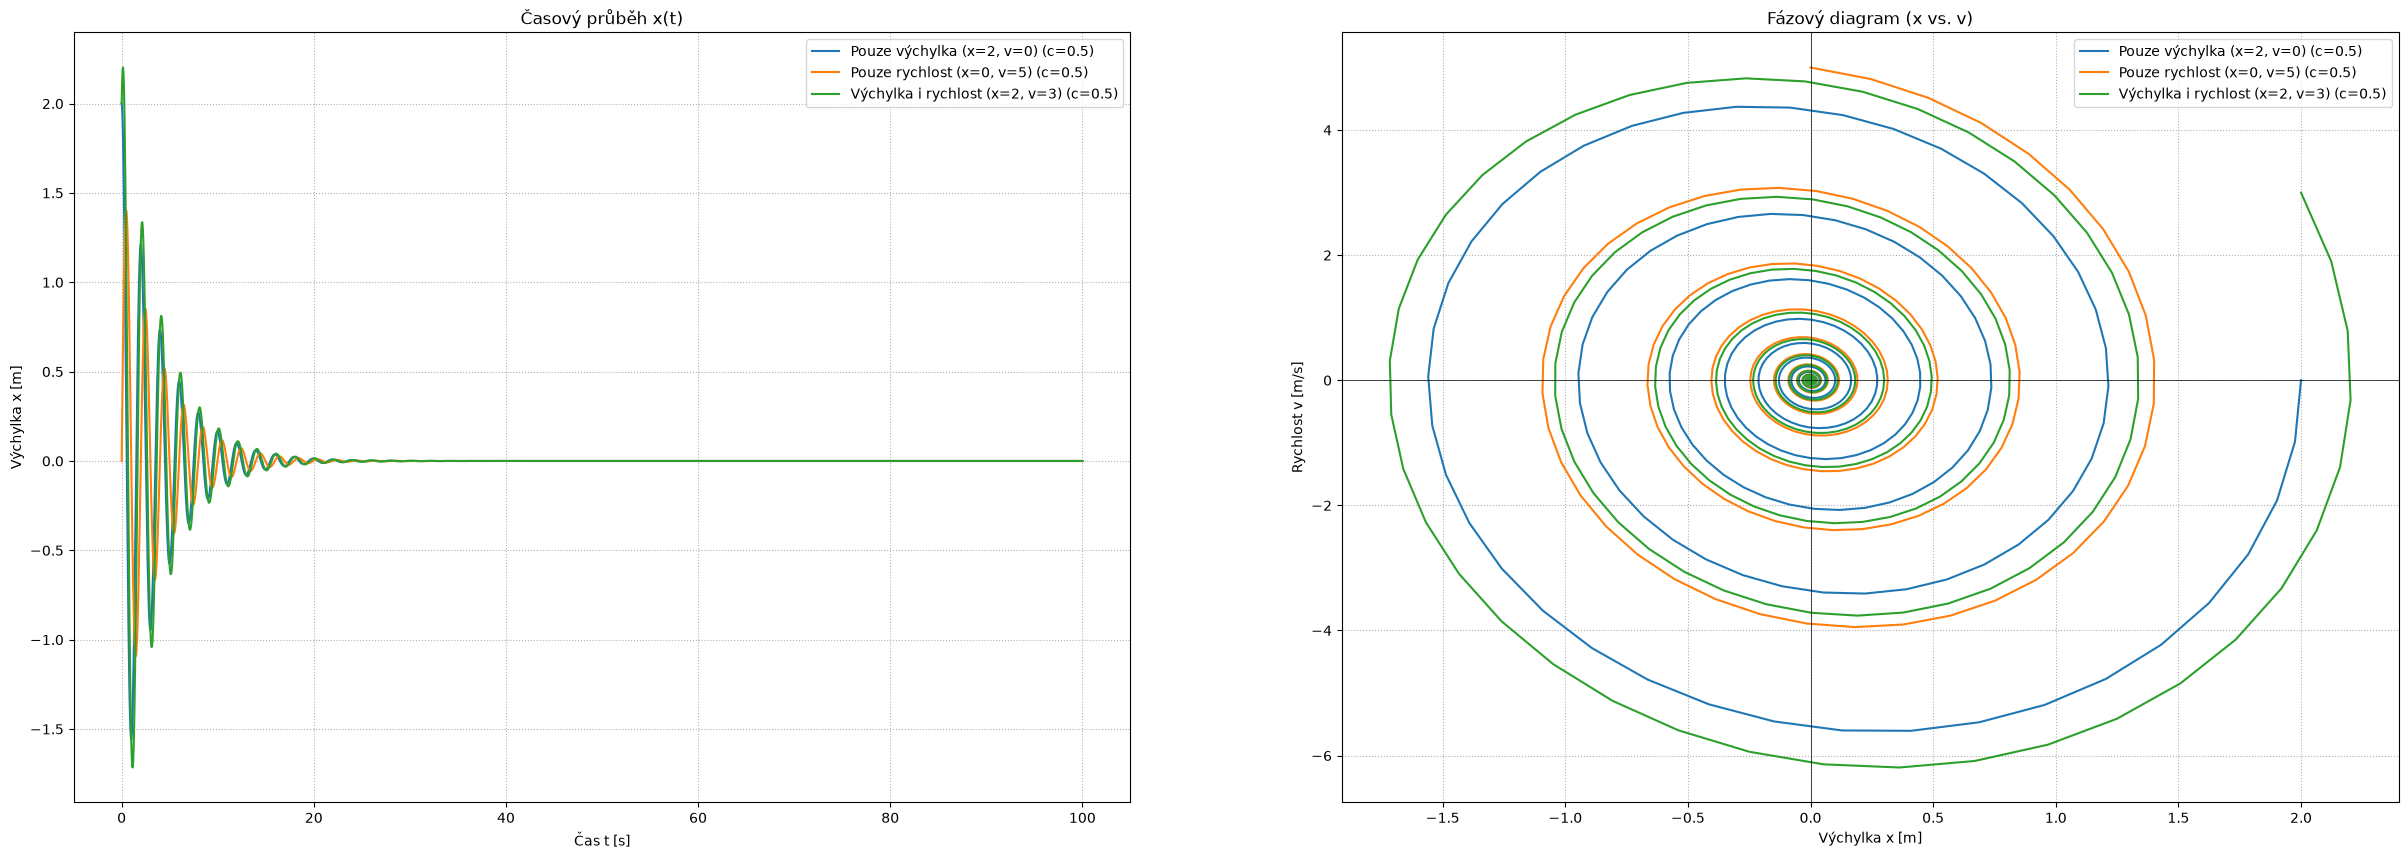

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

def linear_oscilator(stav, t, m, c, k):
    poloha, rychlost = stav
    d_poloha = rychlost
    d_rychlost = -(c / m) * rychlost - (k / m) * poloha
    return [d_poloha, d_rychlost]

casova_osa = np.linspace(0, 100, 2000)
hmotnost = 1.0
tuhost = 10.0

koef_c = 0.5
pocatecni_stavy = [
    ([2.0, 0.0], "Pouze výchylka (x=2, v=0)"),
    ([0.0, 5.0], "Pouze rychlost (x=0, v=5)"),
    ([2.0, 3.0], "Výchylka i rychlost (x=2, v=3)")
]

plt.figure(figsize=(30, 10))

for pocatecni_stav, popisek in pocatecni_stavy:
    reseni = odeint(linear_oscilator, pocatecni_stav, casova_osa, args=(hmotnost, koef_c, tuhost))
    poloha = reseni[:, 0]
    rychlost = reseni[:, 1]
    
    # 1. Graf: Časový průběh x(t)
    plt.subplot(1, 2, 1)
    plt.plot(casova_osa, poloha, label=f"{popisek} (c={koef_c})")
    
    # 2. Graf: Fázový diagram (x vs. v)
    plt.subplot(1, 2, 2)
    plt.plot(poloha, rychlost, label=f"{popisek} (c={koef_c})")

# Úprava 1. grafu
plt.subplot(1, 2, 1)
plt.title("Časový průběh x(t)")
plt.xlabel("Čas t [s]")
plt.ylabel("Výchylka x [m]")
plt.legend()
plt.grid(True, linestyle=":")

# Úprava 2. grafu
plt.subplot(1, 2, 2)
plt.title("Fázový diagram (x vs. v)")
plt.xlabel("Výchylka x [m]")
plt.ylabel("Rychlost v [m/s]")
plt.axhline(0, color="black", lw=0.5)
plt.axvline(0, color="black", lw=0.5)
plt.legend()
plt.grid(True, linestyle=":")

plt.show()

## Nelineární oscilátor

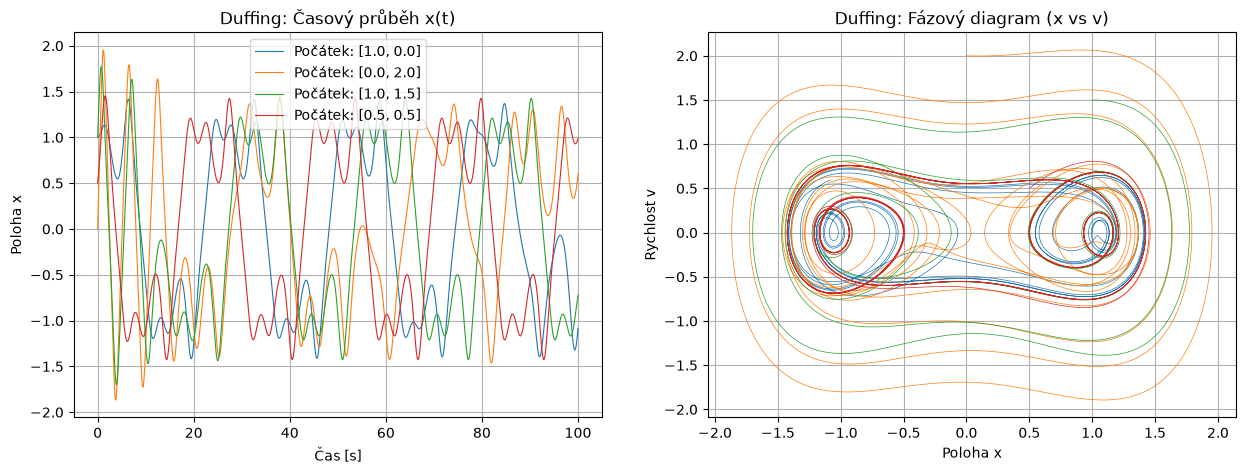

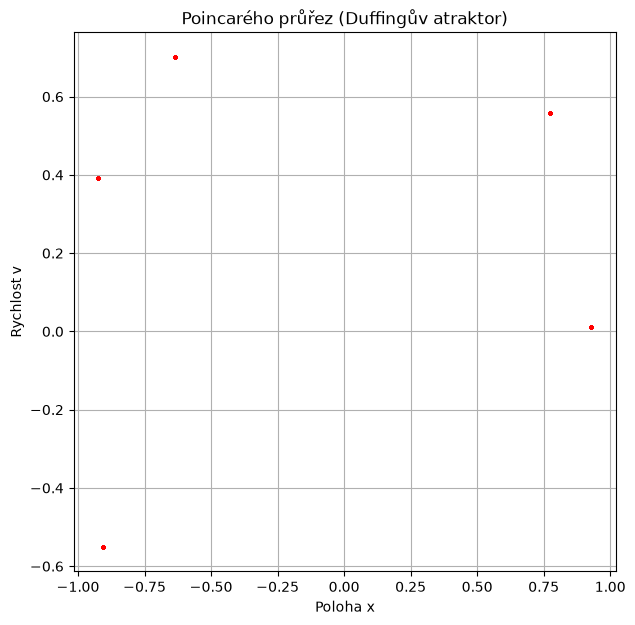

In [10]:
def duffing_oscilator(stav, t, delta, alpha, beta, gamma, omega):
    x, v = stav
    dxdt = v
    dvdt = -delta * v - alpha * x - beta * (x**3) + gamma * np.cos(omega * t)
    return [dxdt, dvdt]

delta, alpha, beta, gamma, omega = 0.2, -1.0, 1.0, 0.3, 1.2
cas_duffing = np.linspace(0, 100, 10000)

pocatecni_podminky = [[1.0, 0.0], [0.0, 2.0], [1.0, 1.5], [0.5, 0.5]]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

for pocatek in pocatecni_podminky:
    vysledek = odeint(duffing_oscilator, pocatek, cas_duffing, args=(delta, alpha, beta, gamma, omega))
    ax1.plot(cas_duffing, vysledek[:, 0], lw=0.8, label="Počátek: " + str(pocatek))
    ax2.plot(vysledek[:, 0], vysledek[:, 1], lw=0.5)

ax1.set_title("Duffing: Časový průběh x(t)")
ax1.set_xlabel("Čas [s]")
ax1.set_ylabel("Poloha x")
ax1.legend()
ax1.grid(True)

ax2.set_title("Duffing: Fázový diagram (x vs v)")
ax2.set_xlabel("Poloha x")
ax2.set_ylabel("Rychlost v")
ax2.grid(True)

plt.show()

T = 2 * np.pi / omega
cas_poincare = np.arange(0, 2000 * T, T)
sol_p = odeint(duffing_oscilator, [0.1, 0.0], cas_poincare, args=(delta, alpha, beta, gamma, omega))

plt.figure(figsize=(7, 7))
plt.scatter(sol_p[100:, 0], sol_p[100:, 1], s=2, color="red")
plt.title("Poincarého průřez (Duffingův atraktor)")
plt.xlabel("Poloha x")
plt.ylabel("Rychlost v")
plt.grid(True)
plt.show()


#### Odpovědi na otázky k Úloze 1
A) Lineární oscilátor
* **Co odlišuje slabé (underdamped), kritické (critical) a silné (overdamped) tlumení?**
  
  Slabé tlumení umožňuje opakované kmitání se zmenšující se amplitudou v čase. Kritické tlumení představuje mezní stav s nejrychlejším návratem do nuly bez překmitu. Je to také hraniční stav mezi kmitavým a nekmitavým pohybem. Silné tlumení pohyb brzdí natolik, že návrat do rovnováhy je pomalý.

* **Jak se změní chování systému, pokud změníme tlumení o několik procent? Je přechod mezi režimy plynulý nebo kvalitativně ostrý?**
  
  Přechod mezi těmito režimy je z hlediska matematiky plynulý (změna kořenů charakteristické rovnice), ale z hlediska chování systému je kvalitativně ostrý – buď systém kmitá, nebo ne.

* **Jaký mechanismus vede k rezonanci u buzeného kmitání?**
  
  Rezonance vzniká při vnějším periodickém buzení, pokud se frekvence budicí síly přiblíží vlastní frekvenci oscilátoru. Dochází k maximálnímu přenosu energie a prudkému nárůstu amplitudy.

* **Dá se problém řešit pomocí symbolické matematiky? Jak?**
  
  Ano, analytické řešení lineárního oscilátoru lze odvodit pomocí symbolické knihovny `SymPy` použitím funkce `dsolve()`.

B) Nelineární oscilátor
* **Dochází pro dané parametry k chaotickému chování?**
  
  Při doporučených parametrech vykazuje systém chaotické chování. To je patrné z fázového diagramu, kde se trajektorie neuzavírá do jednoduchého cyklu, ale tvoří složitý atraktor.

* **Jaký je rozdíl mezi malou a velkou počáteční podmínkou?**
  
  Rozdíl mezi malou a velkou počáteční podmínkou je v tomto nelineárním systému zásadní. Malá výchylka může způsobit, že systém zůstane v jednom z lokálních minim, zatímco velká výchylka mu dodá energii k "přeskakování" mezi potenciálovými jámami.

* **Co se stane, když zvýšíte buzení $\gamma$?**
  
  Zvýšení amplitudy budicí síly $\gamma$ dodává do systému více energie, což vede k přechodu z pravidelných limitních cyklů do stavu plně rozvinutého chaosu.

* **Mění se počet atraktorů?**
  
  Ano, počet atraktorů se v nelineárním systému mění v závislosti na parametrech, zejména na síle buzení.